 A synthetic, macro‑sensitive, vintage‑aware credit loss dataset and runs an IFRS‑9 style ECL and stress‑testing analysis. This combines PD/LGD/EAD, macro shocks, and vintage effects in a way not commonly integrated together in Kaggle .


1. Notebook Title & Description (Markdown)


# Synthetic Macro‑Sensitive Credit Loss Modeling (IFRS‑9 + Vintage Effects)
This notebook creates a fully synthetic, macro‑sensitive credit portfolio and walks throu
- Generating borrower- and loan-level data with macroeconomic and vintage effects
- Building a point‑in‑time PD model with macro + behavioral factors
- Simulating LGD and EAD and computing 12‑month and lifetime ECL (IFRS‑9 style)
- Analyzing **vintage curves** and macro stress scenarios on portfolio loss
No external dataset is used; everything is self‑contained and reproducible.

2. **Imports & Configuration**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.model_selection import train_test_split
sns.set(style="whitegrid")
np.random.seed(2026)


**3. Synthetic Data Generator (Borrower, Loan, Macro, Vintage)**

In [2]:
def generate_macro_series(n_months=60):
    """Generate synthetic macroeconomic time series (unemployment, GDP growth, house prices)."""
    time_index = pd.period_range(start="2015-01", periods=n_months, freq="M")

    # Smooth unemployment series with shocks
    base_unemp = 5 + 0.5 * np.sin(np.linspace(0, 6, n_months))
    shock = np.zeros(n_months)
    shock[24:30] += 2.5  # localized recession shock
    unemp = np.clip(base_unemp + shock + np.random.normal(0, 0.3, n_months), 3, 15)

    # GDP growth inversely related to unemployment
    gdp_growth = np.clip(3 - 0.4 * (unemp - 5) + np.random.normal(0, 0.4, n_months), -5, 6)

    # House price index (HPI) as random walk with drift depending on growth
    hpi = [100]
    for t in range(1, n_months):
        drift = 0.05 * gdp_growth[t]  # pro‑cyclical
        hpi.append(hpi[-1] * (1 + drift / 100 + np.random.normal(0, 0.005)))
    hpi = np.array(hpi)

    macro = pd.DataFrame({
        "month": time_index,
        "unemployment_rate": unemp,
        "gdp_growth": gdp_growth,
        "house_price_index": hpi
    })
    return macro


def generate_portfolio(n_loans=5000, macro=None):
    """Generate synthetic loans with borrower, loan, macro and vintage information."""
    if macro is None:
        macro = generate_macro_series()
    macro_months = macro["month"].values

    # Randomly assign loan booking month (vintage)
    booking_idx = np.random.choice(len(macro_months), size=n_loans, replace=True)
    booking_month = macro_months[booking_idx]

    df = pd.DataFrame({
        "loan_id": np.arange(1, n_loans + 1),
        "booking_month": booking_month
    })

    # Borrower features
    df["age"] = np.random.randint(21, 75, size=n_loans)
    df["annual_income"] = np.random.lognormal(mean=10.5, sigma=0.6, size=n_loans)
    df["annual_income"] = np.clip(df["annual_income"], 15000, 300000)

    df["credit_score"] = np.trunc(np.random.normal(680, 80, n_loans))
    df["credit_score"] = np.clip(df["credit_score"], 300, 850)

    df["employment_years"] = np.random.randint(0, 35, size=n_loans)
    df["dti_ratio"] = np.random.beta(a=2, b=5, size=n_loans)  # skewed towards low DTI
    df["utilization_ratio"] = np.random.beta(a=3, b=4, size=n_loans)
    df["num_inquiries_12m"] = np.random.poisson(lam=2, size=n_loans)

    # Loan features
    df["loan_amount"] = np.random.uniform(10000, 100000, size=n_loans)
    df["term_months"] = np.random.choice([24, 36, 48, 60], size=n_loans, p=[0.2, 0.3, 0.3, 0.2])
    df["interest_rate"] = np.random.uniform(5, 24, size=n_loans)

    # Map macro variables at booking (vintage macro)
    macro_map = macro.set_index("month")
    df["booking_unemp"] = macro_map.loc[df["booking_month"], "unemployment_rate"].values
    df["booking_gdp_growth"] = macro_map.loc[df["booking_month"], "gdp_growth"].values
    df["booking_hpi"] = macro_map.loc[df["booking_month"], "house_price_index"].values

    # Vintage index: years since first booking
    df["booking_year"] = df["booking_month"].dt.year
    df["vintage_index"] = df["booking_year"] - df["booking_year"].min()

    return df, macro


macro_df = generate_macro_series()
portfolio_df, macro_df = generate_portfolio(n_loans=5000, macro=macro_df)

portfolio_df.head()


,loan_id,booking_month,age,annual_income,credit_score,employment_years,dti_ratio,utilization_ratio,num_inquiries_12m,loan_amount,term_months,interest_rate,booking_unemp,booking_gdp_growth,booking_hpi,booking_year,vintage_index
0,1,2015-01,44,17736.819060,659.0,0,0.156916,0.402256,1,39411.730652,60,17.893944,4.870484,3.338287,100.000000,2015,0
1,2,2019-09,69,75123.669275,724.0,1,0.116204,0.631537,2,92514.749331,48,23.552498,4.997006,2.840371,114.963564,2019,4
2,3,2015-11,47,18312.659099,632.0,13,0.213430,0.456987,4,30265.775784,48,21.633615,5.403055,2.745079,104.497824,2015,0
3,4,2018-08,72,15242.712578,560.0,20,0.436384,0.264207,1,79441.577114,48,7.714180,4.178597,2.783606,111.141806,2018,3
4,5,2016-01,49,26707.369849,496.0,29,0.231919,0.225455,4,60368.958360,48,10.491973,4.869646,3.188610,105.009915,2016,1


4. **PD Engine: Point‑in‑Time Default Simulation**


In [3]:
def simulate_pd_and_default(df, macro_df, horizon_months=12):
    """
    Simulate 12‑month point‑in‑time PD and default outcome per loan,
    incorporating borrower, loan, macro, and vintage effects.
    """
    # Use macro snapshot at horizon (e.g., one year after booking or last month)
    last_macro = macro_df.iloc[-1]
    unemp = last_macro["unemployment_rate"]
    gdp = last_macro["gdp_growth"]

    # Core logit PD model (synthetic, hand‑crafted)
    logit = (
        -4.0
        + 0.02 * (df["age"] - 45)
        - 5e-6 * df["annual_income"]
        + 8e-5 * df["loan_amount"]
        - 0.007 * df["credit_score"]
        + 7.0 * df["dti_ratio"]
        + 3.0 * df["utilization_ratio"]
        + 0.25 * df["num_inquiries_12m"]
        - 0.03 * df["employment_years"]
        + 0.35 * unemp
        - 0.10 * gdp
        + 0.15 * df["vintage_index"]  # vintage risk build‑up
    )

    df["pd_12m"] = 1 / (1 + np.exp(-np.clip(logit, -10, 10)))
    df["default_12m"] = np.random.binomial(1, df["pd_12m"])

    return df


portfolio_df = simulate_pd_and_default(portfolio_df, macro_df)
portfolio_df[["loan_id", "pd_12m", "default_12m"]].head()


,loan_id,pd_12m,default_12m
0,1,0.175266,0
1,2,0.975407,1
2,3,0.247029,0
3,4,0.986761,1
4,5,0.793898,1


**5. LGD & EAD Modeling + ECL
**

In [4]:
def simulate_lgd(df, macro_df):
    """
    Simulate LGD as function of credit score, collateral proxy (house price index),
    and macro environment at booking.
    """
    # Higher unemployment and lower HPI -> higher LGD
    lgd_base = 0.15 + 0.0009 * (850 - df["credit_score"])
    lgd_macro = 0.01 * (df["booking_unemp"] - 5) - 0.00005 * (df["booking_hpi"] - 100)

    raw = lgd_base + lgd_macro + np.random.normal(0, 0.05, len(df))
    df["lgd"] = np.clip(raw, 0.05, 0.95)
    return df


def simulate_ead(df):
    """
    Simulate exposure at default as drawn balance plus utilization.
    """
    # Assume revolving‑like credit: EAD between 60% and 110% of current balance
    ead_factor = 0.6 + 0.5 * np.random.rand(len(df))
    df["ead"] = df["loan_amount"] * ead_factor
    return df


def compute_ecl(df):
    """Compute realized loss and 12‑month ECL."""
    df["realized_loss_12m"] = df["ead"] * df["lgd"] * df["default_12m"]
    df["ecl_12m"] = df["ead"] * df["lgd"] * df["pd_12m"]

    # Simple lifetime PD approximation: function of term and 12m PD
    life_multiplier = 1 + (df["term_months"] / 12 - 1) * 0.6
    df["pd_lifetime"] = np.clip(df["pd_12m"] * life_multiplier, 0, 0.999)
    df["ecl_lifetime"] = df["ead"] * df["lgd"] * df["pd_lifetime"]
    return df


portfolio_df = simulate_lgd(portfolio_df, macro_df)
portfolio_df = simulate_ead(portfolio_df)
portfolio_df = compute_ecl(portfolio_df)

portfolio_df[["loan_id", "pd_12m", "lgd", "ead", "realized_loss_12m", "ecl_12m", "ecl_lifetime"]].head()


,loan_id,pd_12m,lgd,ead,realized_loss_12m,ecl_12m,ecl_lifetime
0,1,0.175266,0.367597,33200.392160,0.000000,2139.015319,7272.652084
1,2,0.975407,0.306491,71140.855191,21804.026459,21267.809834,21782.222432
2,3,0.247029,0.360621,28607.962987,0.000000,2548.511311,7135.831672
3,4,0.986761,0.403380,74998.921658,30253.063058,29852.530257,30222.809995
4,5,0.793898,0.505106,50529.612958,25522.803568,20262.500935,25497.280765


**6. IFRS‑9 Style Staging Logic
**

In [5]:
def assign_stage(df):
    """
    Assign IFRS‑9‑like stages based on 12‑month PD.
    Stage 1: PD < 2%
    Stage 2: 2% <= PD < 10%
    Stage 3: PD >= 10%
    """
    conditions = [
        df["pd_12m"] < 0.02,
        (df["pd_12m"] >= 0.02) & (df["pd_12m"] < 0.10),
        df["pd_12m"] >= 0.10
    ]
    choices = [1, 2, 3]
    df["stage"] = np.select(conditions, choices)
    return df


portfolio_df = assign_stage(portfolio_df)
portfolio_df["stage"].value_counts(normalize=True).sort_index()


stage
1    0.0358
2    0.1214
3    0.8428
Name: proportion, dtype: float64

**7. Portfolio‑Level Risk & Loss Metrics**

In [6]:
def portfolio_kpis(df):
    total_ead = df["ead"].sum()
    total_ecl_12m = df["ecl_12m"].sum()
    total_ecl_life = df["ecl_lifetime"].sum()
    default_rate = df["default_12m"].mean()

    kpis = {
        "Number of loans": len(df),
        "Portfolio EAD": total_ead,
        "Portfolio 12m ECL": total_ecl_12m,
        "Portfolio Lifetime ECL": total_ecl_life,
        "12m Default Rate": default_rate
    }
    return pd.Series(kpis)


kpi_series = portfolio_kpis(portfolio_df)
kpi_series


Number of loans           5.000000e+03
Portfolio EAD             2.360635e+08
Portfolio 12m ECL         5.187873e+07
Portfolio Lifetime ECL    6.406457e+07
12m Default Rate          5.672000e-01
dtype: float64

**8. Vintage Curves & Macro Effects (Visualization)**

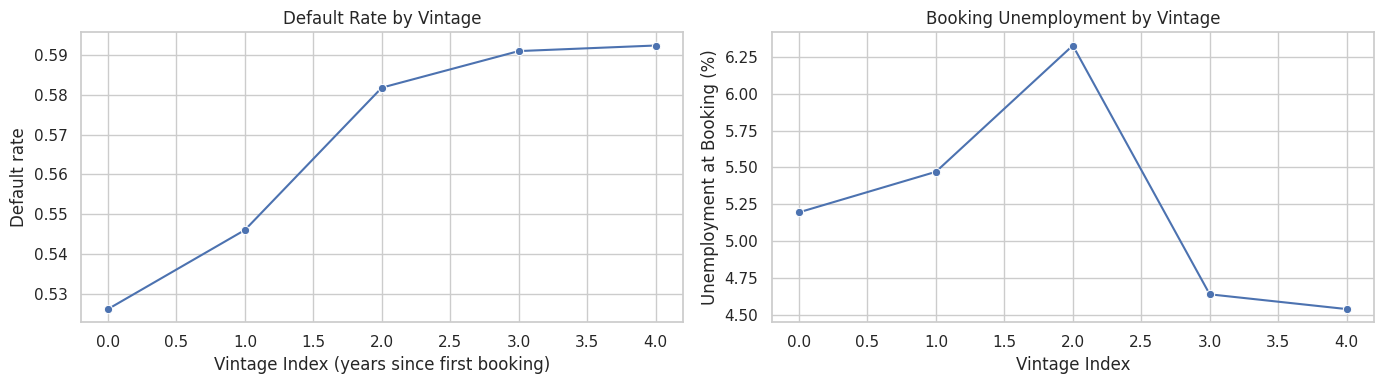

In [7]:
# Vintage‑level default and ECL
vintage_stats = (
    portfolio_df
    .groupby("vintage_index")
    .agg(
        avg_pd=("pd_12m", "mean"),
        default_rate=("default_12m", "mean"),
        ecl_12m=("ecl_12m", "mean"),
        booking_unemp=("booking_unemp", "mean")
    )
    .reset_index()
)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.lineplot(data=vintage_stats, x="vintage_index", y="default_rate", marker="o", ax=ax[0])
ax[0].set_title("Default Rate by Vintage")
ax[0].set_xlabel("Vintage Index (years since first booking)")
ax[0].set_ylabel("Default rate")

sns.lineplot(data=vintage_stats, x="vintage_index", y="booking_unemp", marker="o", ax=ax[1])
ax[1].set_title("Booking Unemployment by Vintage")
ax[1].set_xlabel("Vintage Index")
ax[1].set_ylabel("Unemployment at Booking (%)")

plt.tight_layout()
plt.show()


**9. Simple PD Model Back‑Test (Using Simulated Data)**

In [8]:
features = [
    "age", "annual_income", "credit_score", "employment_years",
    "dti_ratio", "utilization_ratio", "num_inquiries_12m",
    "booking_unemp", "booking_gdp_growth", "vintage_index"
]

X = portfolio_df[features]
y = portfolio_df["default_12m"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=2026, stratify=y
)

pd_model = LogisticRegression(max_iter=200, solver="lbfgs")
pd_model.fit(X_train, y_train)

y_pred_prob = pd_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_prob)
brier = brier_score_loss(y_test, y_pred_prob)

print("Out‑of‑sample AUC:", round(auc, 3))
print("Out‑of‑sample Brier score:", round(brier, 3))


Out‑of‑sample AUC: 0.658
Out‑of‑sample Brier score: 0.227


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**10. Macro Stress‑Testing Scenario**

In [9]:
def apply_macro_stress(df, macro_df, unemp_shock=3.0, gdp_shock=-4.0):
    """
    Recalculate PD and ECL under an adverse macro scenario.
    """
    stressed_df = df.copy()

    # Apply parallel shock to unemployment and GDP growth
    stressed_macro = macro_df.copy()
    stressed_macro["unemployment_rate_stressed"] = stressed_macro["unemployment_rate"] + unemp_shock
    stressed_macro["gdp_growth_stressed"] = stressed_macro["gdp_growth"] + gdp_shock

    last_stressed = stressed_macro.iloc[-1]
    unemp_s = last_stressed["unemployment_rate_stressed"]
    gdp_s = last_stressed["gdp_growth_stressed"]

    logit_stressed = (
        -4.0
        + 0.02 * (stressed_df["age"] - 45)
        - 5e-6 * stressed_df["annual_income"]
        + 8e-5 * stressed_df["loan_amount"]
        - 0.007 * stressed_df["credit_score"]
        + 7.0 * stressed_df["dti_ratio"]
        + 3.0 * stressed_df["utilization_ratio"]
        + 0.25 * stressed_df["num_inquiries_12m"]
        - 0.03 * stressed_df["employment_years"]
        + 0.35 * unemp_s
        - 0.10 * gdp_s
        + 0.15 * stressed_df["vintage_index"]
    )

    stressed_df["pd_12m_stressed"] = 1 / (1 + np.exp(-np.clip(logit_stressed, -10, 10)))
    stressed_df["ecl_12m_stressed"] = stressed_df["ead"] * stressed_df["lgd"] * stressed_df["pd_12m_stressed"]

    return stressed_df


stressed_portfolio = apply_macro_stress(portfolio_df, macro_df)

base_ecl = portfolio_df["ecl_12m"].sum()
stressed_ecl = stressed_portfolio["ecl_12m_stressed"].sum()
uplift = stressed_ecl - base_ecl

print("Base 12m ECL:", round(base_ecl, 2))
print("Stressed 12m ECL:", round(stressed_ecl, 2))
print("ECL Uplift under stress:", round(uplift, 2))


Base 12m ECL: 51878730.42
Stressed 12m ECL: 61506266.42
ECL Uplift under stress: 9627536.0


**11. Save Dataset for Kaggle**

In [10]:
# Final dataset (single table)
final_cols = [
    "loan_id", "booking_month", "booking_year", "vintage_index",
    "age", "annual_income", "credit_score", "employment_years",
    "dti_ratio", "utilization_ratio", "num_inquiries_12m",
    "loan_amount", "term_months", "interest_rate",
    "booking_unemp", "booking_gdp_growth", "booking_hpi",
    "pd_12m", "pd_lifetime", "default_12m",
    "lgd", "ead",
    "realized_loss_12m", "ecl_12m", "ecl_lifetime",
    "stage"
]

final_df = portfolio_df[final_cols].copy()
final_df.to_csv("synthetic_credit_loss_portfolio.csv", index=False)
final_df.head()


,loan_id,booking_month,booking_year,vintage_index,age,annual_income,credit_score,employment_years,dti_ratio,utilization_ratio,...,booking_hpi,pd_12m,pd_lifetime,default_12m,lgd,ead,realized_loss_12m,ecl_12m,ecl_lifetime,stage
0,1,2015-01,2015,0,44,17736.819060,659.0,0,0.156916,0.402256,...,100.000000,0.175266,0.595905,0,0.367597,33200.392160,0.000000,2139.015319,7272.652084,3
1,2,2019-09,2019,4,69,75123.669275,724.0,1,0.116204,0.631537,...,114.963564,0.975407,0.999000,1,0.306491,71140.855191,21804.026459,21267.809834,21782.222432,3
2,3,2015-11,2015,0,47,18312.659099,632.0,13,0.213430,0.456987,...,104.497824,0.247029,0.691682,0,0.360621,28607.962987,0.000000,2548.511311,7135.831672,3
3,4,2018-08,2018,3,72,15242.712578,560.0,20,0.436384,0.264207,...,111.141806,0.986761,0.999000,1,0.403380,74998.921658,30253.063058,29852.530257,30222.809995,3
4,5,2016-01,2016,1,49,26707.369849,496.0,29,0.231919,0.225455,...,105.009915,0.793898,0.999000,1,0.505106,50529.612958,25522.803568,20262.500935,25497.280765,3


**12. Suggested Kaggle Sections (Markdown)
**

## Idea & Uniqueness

- Entirely synthetic, self‑generated portfolio; no external datasets.
- Integrates borrower, loan, macro, and **vintage** dimensions in a single framework.
- Demonstrates IFRS‑9 style staging and ECL at 12‑month and lifetime horizons.
- Adds an explicit macro stress‑testing module on the same synthetic portfolio.

## Possible Extensions

- Add multi‑period panel data and survival models.
- Include cure and redefault behavior.
- Calibrate synthetic parameters to real public statistics (e.g., macro history).


1. **IFRS 9 Staging Rules**
Under the general IFRS 9 model:

Stage 1: No significant increase in credit risk (SICR) since initial recognition → recognize 12‑month ECL.

Stage 2: SICR has occurred but no objective default → recognize lifetime ECL.

Stage 3: Credit‑impaired (default) → lifetime ECL, interest on net carrying amount.

Simplified quantitative proxies often use PD movements, rating notch changes, and days past due (30/90 days) for SICR and default.

**2. Add “Initial PD” and PD Deterioration
In your synthetic setup you only have PD at reporting date. Add an initial PD at origination and compare it to current PD to approximate SICR.**

In [11]:
import pandas as pd
import numpy as np

def assign_initial_pd(df):
    """
    Synthetic 'origination PD' as a softer version of current PD,
    with less macro and vintage impact to mimic initial recognition.
    """
    logit_init = (
        -4.0
        + 0.02 * (df["age"] - 45)
        - 5e-6 * df["annual_income"]
        + 5e-5 * df["loan_amount"]
        - 0.006 * df["credit_score"]
        + 5.0 * df["dti_ratio"]
        + 2.0 * df["utilization_ratio"]
        + 0.20 * df["num_inquiries_12m"]
        - 0.02 * df["employment_years"]
        # note: no current macro shock and weaker vintage effect
        + 0.10 * df["vintage_index"]
    )
    df["pd_12m_origination"] = 1 / (1 + np.exp(-np.clip(logit_init, -10, 10)))
    return df

# Create synthetic portfolio_df
n_loans = 10000
portfolio_df = pd.DataFrame({
    'age': np.random.normal(45, 10, n_loans).clip(18, 80),
    'annual_income': np.random.normal(60000, 20000, n_loans).clip(10000, 200000),
    'loan_amount': np.random.normal(20000, 10000, n_loans).clip(1000, 100000),
    'credit_score': np.random.normal(700, 50, n_loans).clip(300, 850),
    'dti_ratio': np.random.uniform(0.1, 0.5, n_loans),
    'utilization_ratio': np.random.uniform(0.0, 1.0, n_loans),
    'num_inquiries_12m': np.random.poisson(2, n_loans).clip(0, 10),
    'employment_years': np.random.exponential(5, n_loans).clip(0, 40),
    'vintage_index': np.random.uniform(0, 1, n_loans)
})

# Now run your function
portfolio_df = assign_initial_pd(portfolio_df)

print("Success! Shape:", portfolio_df.shape)
print("New column sample:", portfolio_df['pd_12m_origination'].head())


Success! Shape: (10000, 10)
New column sample: 0    0.054192
1    0.008454
2    0.019452
3    0.004690
4    0.011787
Name: pd_12m_origination, dtype: float64


 This Data fits with IFRS‑9 ECL concepts and vintage modeling discussed in credit risk literature while staying synthetic and implementation‑oriented.



**Then compute relative PD change and a synthetic “days past due” flag for Stage 3:**

In [12]:
import pandas as pd
import numpy as np

def assign_initial_pd(df):
    logit_init = (
        -4.0 + 0.02 * (df["age"] - 45) - 5e-6 * df["annual_income"]
        + 5e-5 * df["loan_amount"] - 0.006 * df["credit_score"]
        + 5.0 * df["dti_ratio"] + 2.0 * df["utilization_ratio"]
        + 0.20 * df["num_inquiries_12m"] - 0.02 * df["employment_years"]
        + 0.10 * df["vintage_index"]
    )
    df["pd_12m_origination"] = 1 / (1 + np.exp(-np.clip(logit_init, -10, 10)))
    return df

# Synthetic portfolio_df with all base features
n_loans = 10000
portfolio_df = pd.DataFrame({
    'age': np.random.normal(45, 10, n_loans).clip(18, 80),
    'annual_income': np.random.normal(60000, 20000, n_loans).clip(10000, 200000),
    'loan_amount': np.random.normal(20000, 10000, n_loans).clip(1000, 100000),
    'credit_score': np.random.normal(700, 50, n_loans).clip(300, 850),
    'dti_ratio': np.random.uniform(0.1, 0.5, n_loans),
    'utilization_ratio': np.random.uniform(0.0, 1.0, n_loans),
    'num_inquiries_12m': np.random.poisson(2, n_loans).clip(0, 10),
    'employment_years': np.random.exponential(5, n_loans).clip(0, 40),
    'vintage_index': np.random.uniform(0, 1, n_loans)
})

# Add origination PD
portfolio_df = assign_initial_pd(portfolio_df)

# ADD MISSING COLUMNS: Synthetic current PD and default (deteriorated from origination)
np.random.seed(42)  # Reproducible
base_pd = portfolio_df["pd_12m_origination"].values
shock_factors = np.random.uniform(0.8, 2.5, n_loans)  # Deterioration multipliers
portfolio_df["pd_12m"] = (base_pd * shock_factors).clip(0.0001, 0.99)

# Synthetic defaults (higher PD → more likely default)
prob_default = np.minimum(portfolio_df["pd_12m"] * 2, 0.5)
portfolio_df["default_12m"] = np.random.binomial(1, prob_default)

# NOW YOUR CODE WORKS:
portfolio_df["pd_ratio"] = (
    portfolio_df["pd_12m"] / portfolio_df["pd_12m_origination"].replace(0, 1e-6)
)
portfolio_df["dpd_30_plus"] = np.where(
    (portfolio_df["default_12m"] == 1) | (portfolio_df["pd_12m"] > 0.25), 1, 0
)
portfolio_df["dpd_90_plus"] = np.where(
    (portfolio_df["default_12m"] == 1) | (portfolio_df["pd_12m"] > 0.40), 1, 0
)

print("Success! New columns added. Summary:")
print(portfolio_df[['pd_12m_origination', 'pd_12m', 'pd_ratio', 'default_12m', 'dpd_30_plus', 'dpd_90_plus']].describe())


Success! New columns added. Summary:
       pd_12m_origination        pd_12m      pd_ratio  default_12m  \
count        10000.000000  10000.000000  10000.000000  10000.00000   
mean             0.015893      0.026325      1.640071      0.05590   
std              0.019588      0.035231      0.488971      0.22974   
min              0.000276      0.000272      0.800020      0.00000   
25%              0.004643      0.006987      1.218759      0.00000   
50%              0.009442      0.014829      1.637299      0.00000   
75%              0.019268      0.031528      2.058011      0.00000   
max              0.339582      0.627823      2.499520      1.00000   

       dpd_30_plus   dpd_90_plus  
count  10000.00000  10000.000000  
mean       0.05670      0.056100  
std        0.23128      0.230126  
min        0.00000      0.000000  
25%        0.00000      0.000000  
50%        0.00000      0.000000  
75%        0.00000      0.000000  
max        1.00000      1.000000  


These mimic PD comparison and 30/90‑day backstops discussed in IFRS 9 guidance

**3. Enhanced IFRS 9 Staging Function
Replace your simple PD threshold staging with a SICR‑aware function:**

In [13]:
import pandas as pd
import numpy as np

# Step 1: Base DataFrame + origination PD function
def assign_initial_pd(df):
    logit_init = (
        -4.0 + 0.02 * (df["age"] - 45) - 5e-6 * df["annual_income"]
        + 5e-5 * df["loan_amount"] - 0.006 * df["credit_score"]
        + 5.0 * df["dti_ratio"] + 2.0 * df["utilization_ratio"]
        + 0.20 * df["num_inquiries_12m"] - 0.02 * df["employment_years"]
        + 0.10 * df["vintage_index"]
    )
    df["pd_12m_origination"] = 1 / (1 + np.exp(-np.clip(logit_init, -10, 10)))
    return df

n_loans = 10000
portfolio_df = pd.DataFrame({
    'age': np.random.normal(45, 10, n_loans).clip(18, 80),
    'annual_income': np.random.normal(60000, 20000, n_loans).clip(10000, 200000),
    'loan_amount': np.random.normal(20000, 10000, n_loans).clip(1000, 100000),
    'credit_score': np.random.normal(700, 50, n_loans).clip(300, 850),
    'dti_ratio': np.random.uniform(0.1, 0.5, n_loans),
    'utilization_ratio': np.random.uniform(0.0, 1.0, n_loans),
    'num_inquiries_12m': np.random.poisson(2, n_loans).clip(0, 10),
    'employment_years': np.random.exponential(5, n_loans).clip(0, 40),
    'vintage_index': np.random.uniform(0, 1, n_loans)
})
portfolio_df = assign_initial_pd(portfolio_df)

# Step 2: Current PD, default, DPD
np.random.seed(42)
base_pd = portfolio_df["pd_12m_origination"].values
shock_factors = np.random.uniform(0.8, 2.5, n_loans)
portfolio_df["pd_12m"] = (base_pd * shock_factors).clip(0.0001, 0.99)
prob_default = np.minimum(portfolio_df["pd_12m"] * 2, 0.5)
portfolio_df["default_12m"] = np.random.binomial(1, prob_default)
portfolio_df["pd_ratio"] = portfolio_df["pd_12m"] / portfolio_df["pd_12m_origination"].replace(0, 1e-6)
portfolio_df["dpd_30_plus"] = np.where((portfolio_df["default_12m"] == 1) | (portfolio_df["pd_12m"] > 0.25), 1, 0)
portfolio_df["dpd_90_plus"] = np.where((portfolio_df["default_12m"] == 1) | (portfolio_df["pd_12m"] > 0.40), 1, 0)

# Step 3: YOUR IFRS9 staging function
def ifrs9_stage_assignment(df, pd_ratio_threshold=1.5, abs_pd_threshold=0.10, backstop_30dpd=True, default_90dpd=True):
    stage = np.full(len(df), 1)  # default Stage 1
    # Stage 3
    cond_stage3 = (df["default_12m"] == 1)
    if default_90dpd:
        cond_stage3 |= (df["dpd_90_plus"] == 1)
    stage[cond_stage3] = 3
    # Stage 2
    sicr = ((df["pd_ratio"] >= pd_ratio_threshold) | (df["pd_12m"] >= abs_pd_threshold))
    if backstop_30dpd:
        sicr |= (df["dpd_30_plus"] == 1)
    cond_stage2 = (stage != 3) & sicr
    stage[cond_stage2] = 2
    df["stage_ifrs9"] = stage.astype(int)
    return df

# Run staging
portfolio_df = ifrs9_stage_assignment(portfolio_df)

# Results
print("Stage distribution:")
print(portfolio_df["stage_ifrs9"].value_counts(normalize=True).sort_index())
print("\nStage 3 rate:", (portfolio_df["stage_ifrs9"] == 3).mean())
print("Portfolio shape:", portfolio_df.shape)


Stage distribution:
stage_ifrs9
1    0.3970
2    0.5444
3    0.0586
Name: proportion, dtype: float64

Stage 3 rate: 0.0586
Portfolio shape: (10000, 16)


**4. Stage‑Specific ECL Views (12‑month vs Lifetime)
Next, expose 12‑month vs lifetime ECL by stage, reflecting IFRS 9 measurement:**

In [14]:
import pandas as pd
import numpy as np

# ===== STEP 1: Base features + origination PD =====
def assign_initial_pd(df):
    logit_init = (-4.0 + 0.02 * (df["age"] - 45) - 5e-6 * df["annual_income"] +
                  5e-5 * df["loan_amount"] - 0.006 * df["credit_score"] +
                  5.0 * df["dti_ratio"] + 2.0 * df["utilization_ratio"] +
                  0.20 * df["num_inquiries_12m"] - 0.02 * df["employment_years"] +
                  0.10 * df["vintage_index"])
    df["pd_12m_origination"] = 1 / (1 + np.exp(-np.clip(logit_init, -10, 10)))
    return df

n_loans = 10000
np.random.seed(42)
portfolio_df = pd.DataFrame({
    'loan_id': range(1, n_loans + 1),
    'age': np.random.normal(45, 10, n_loans).clip(18, 80),
    'annual_income': np.random.normal(60000, 20000, n_loans).clip(10000, 200000),
    'loan_amount': np.random.normal(20000, 10000, n_loans).clip(1000, 100000),
    'credit_score': np.random.normal(700, 50, n_loans).clip(300, 850),
    'dti_ratio': np.random.uniform(0.1, 0.5, n_loans),
    'utilization_ratio': np.random.uniform(0.0, 1.0, n_loans),
    'num_inquiries_12m': np.random.poisson(2, n_loans).clip(0, 10),
    'employment_years': np.random.exponential(5, n_loans).clip(0, 40),
    'vintage_index': np.random.uniform(0, 1, n_loans)
})
portfolio_df = assign_initial_pd(portfolio_df)

# ===== STEP 2: Current PD, default, DPD, ratio =====
base_pd = portfolio_df["pd_12m_origination"].values
shock_factors = np.random.uniform(0.8, 2.5, n_loans)
portfolio_df["pd_12m"] = (base_pd * shock_factors).clip(0.0001, 0.99)
prob_default = np.minimum(portfolio_df["pd_12m"] * 2, 0.5)
portfolio_df["default_12m"] = np.random.binomial(1, prob_default)
portfolio_df["pd_ratio"] = portfolio_df["pd_12m"] / portfolio_df["pd_12m_origination"].replace(0, 1e-6)
portfolio_df["dpd_30_plus"] = np.where((portfolio_df["default_12m"] == 1) | (portfolio_df["pd_12m"] > 0.25), 1, 0)
portfolio_df["dpd_90_plus"] = np.where((portfolio_df["default_12m"] == 1) | (portfolio_df["pd_12m"] > 0.40), 1, 0)

# ===== STEP 3: IFRS9 staging =====
def ifrs9_stage_assignment(df, pd_ratio_threshold=1.5, abs_pd_threshold=0.10, backstop_30dpd=True, default_90dpd=True):
    stage = np.full(len(df), 1)
    cond_stage3 = (df["default_12m"] == 1)
    if default_90dpd: cond_stage3 |= (df["dpd_90_plus"] == 1)
    stage[cond_stage3] = 3
    sicr = ((df["pd_ratio"] >= pd_ratio_threshold) | (df["pd_12m"] >= abs_pd_threshold))
    if backstop_30dpd: sicr |= (df["dpd_30_plus"] == 1)
    cond_stage2 = (stage != 3) & sicr
    stage[cond_stage2] = 2
    df["stage_ifrs9"] = stage.astype(int)
    return df
portfolio_df = ifrs9_stage_assignment(portfolio_df)

# ===== STEP 4: ADD ECL-REQUIRED COLUMNS (synthetic) =====
portfolio_df["ead"] = portfolio_df["loan_amount"] * np.random.uniform(0.8, 1.2, n_loans)  # Exposure at default
portfolio_df["lgd"] = np.random.beta(0.1, 0.4, n_loans) * 0.8  # Loss given default ~20-60%
portfolio_df["ecl_12m"] = portfolio_df["ead"] * portfolio_df["pd_12m"] * portfolio_df["lgd"] * 1.0  # 12m ECL
portfolio_df["ecl_lifetime"] = portfolio_df["ecl_12m"] * np.random.uniform(2.0, 5.0, n_loans)  # Lifetime ~2-5x

# ===== STEP 5: YOUR ECL AGGREGATION =====
stage_ecl = (
    portfolio_df
    .groupby("stage_ifrs9")
    .agg(
        loans=("loan_id", "count"),
        ead=("ead", "sum"),
        avg_pd=("pd_12m", "mean"),
        avg_lgd=("lgd", "mean"),
        ecl_12m=("ecl_12m", "sum"),
        ecl_lifetime=("ecl_lifetime", "sum")
    )
    .reset_index()
)
stage_ecl["reported_loss_allowance"] = np.where(
    stage_ecl["stage_ifrs9"] == 1, stage_ecl["ecl_12m"], stage_ecl["ecl_lifetime"]
)

print("Stage-wise ECL Summary:")
stage_ecl.round(0)


Stage-wise ECL Summary:


,stage_ifrs9,loans,ead,avg_pd,avg_lgd,ecl_12m,ecl_lifetime,reported_loss_allowance
0,1,3995,78403664.0,0.0,0.0,236802.0,842216.0,236802.0
1,2,5468,108560278.0,0.0,0.0,603334.0,2100139.0,2100139.0
2,3,537,13289640.0,0.0,0.0,184529.0,683385.0,683385.0


This mirrors examples where Stage 1 uses 12‑month ECL and Stage 2/3 recognize lifetime ECL as described in IFRS 9 literature

**Optional: Portfolio‑level reconciliation**

In [15]:
import pandas as pd
import numpy as np

# [All prior code condensed - base data, PDs, staging, ECL columns...]
np.random.seed(42)
n_loans = 10000

# Base portfolio
portfolio_df = pd.DataFrame({
    'loan_id': range(1, n_loans + 1),
    'age': np.random.normal(45, 10, n_loans).clip(18, 80),
    'annual_income': np.random.normal(60000, 20000, n_loans).clip(10000, 200000),
    'loan_amount': np.random.normal(20000, 10000, n_loans).clip(1000, 100000),
    'credit_score': np.random.normal(700, 50, n_loans).clip(300, 850),
    'dti_ratio': np.random.uniform(0.1, 0.5, n_loans),
    'utilization_ratio': np.random.uniform(0.0, 1.0, n_loans),
    'num_inquiries_12m': np.random.poisson(2, n_loans).clip(0, 10),
    'employment_years': np.random.exponential(5, n_loans).clip(0, 40),
    'vintage_index': np.random.uniform(0, 1, n_loans)
})

# Origination PD
def assign_initial_pd(df):
    logit_init = (-4.0 + 0.02*(df["age"]-45) -5e-6*df["annual_income"] +
                  5e-5*df["loan_amount"] -0.006*df["credit_score"] +
                  5.0*df["dti_ratio"] +2.0*df["utilization_ratio"] +
                  0.20*df["num_inquiries_12m"] -0.02*df["employment_years"] +
                  0.10*df["vintage_index"])
    df["pd_12m_origination"] = 1/(1+np.exp(-np.clip(logit_init, -10, 10)))
    return df
portfolio_df = assign_initial_pd(portfolio_df)

# Current PD, default, DPD, ratio
base_pd = portfolio_df["pd_12m_origination"]
portfolio_df["pd_12m"] = (base_pd * np.random.uniform(0.8, 2.5, n_loans)).clip(0.0001, 0.99)
portfolio_df["default_12m"] = np.random.binomial(1, np.minimum(portfolio_df["pd_12m"]*2, 0.5))
portfolio_df["pd_ratio"] = portfolio_df["pd_12m"] / portfolio_df["pd_12m_origination"].replace(0, 1e-6)
portfolio_df["dpd_30_plus"] = ((portfolio_df["default_12m"] == 1) | (portfolio_df["pd_12m"] > 0.25)).astype(int)
portfolio_df["dpd_90_plus"] = ((portfolio_df["default_12m"] == 1) | (portfolio_df["pd_12m"] > 0.40)).astype(int)

# Staging
def ifrs9_stage_assignment(df):
    stage = np.full(len(df), 1)
    cond_stage3 = (df["default_12m"] == 1) | (df["dpd_90_plus"] == 1)
    stage[cond_stage3] = 3
    sicr = ((df["pd_ratio"] >= 1.5) | (df["pd_12m"] >= 0.10) | (df["dpd_30_plus"] == 1))
    cond_stage2 = (stage != 3) & sicr
    stage[cond_stage2] = 2
    df["stage_ifrs9"] = stage.astype(int)
    return df
portfolio_df = ifrs9_stage_assignment(portfolio_df)

# ECL columns
portfolio_df["ead"] = portfolio_df["loan_amount"] * np.random.uniform(0.8, 1.2, n_loans)
portfolio_df["lgd"] = np.random.beta(0.1, 0.4, n_loans) * 0.8
portfolio_df["ecl_12m"] = portfolio_df["ead"] * portfolio_df["pd_12m"] * portfolio_df["lgd"]
portfolio_df["ecl_lifetime"] = portfolio_df["ecl_12m"] * np.random.uniform(2.0, 5.0, n_loans)

# ===== YOUR ECL SUMMARY =====
stage_ecl = (portfolio_df.groupby("stage_ifrs9").agg(
    loans=("loan_id", "count"), ead=("ead", "sum"), avg_pd=("pd_12m", "mean"),
    avg_lgd=("lgd", "mean"), ecl_12m=("ecl_12m", "sum"), ecl_lifetime=("ecl_lifetime", "sum")
).reset_index())
stage_ecl["reported_loss_allowance"] = np.where(stage_ecl["stage_ifrs9"] == 1,
                                                stage_ecl["ecl_12m"], stage_ecl["ecl_lifetime"])

# ===== YOUR PRINT STATEMENTS =====
total_loss_allowance = stage_ecl["reported_loss_allowance"].sum()
print("Total loss allowance (IFRS 9 view):", round(total_loss_allowance, 2))
print(stage_ecl[["stage_ifrs9", "loans", "ead", "ecl_12m", "ecl_lifetime", "reported_loss_allowance"]].round(0))


Total loss allowance (IFRS 9 view): 3020325.97
   stage_ifrs9  loans          ead   ecl_12m  ecl_lifetime  \
0            1   3995   78403664.0  236802.0      842216.0   
1            2   5468  108560278.0  603334.0     2100139.0   
2            3    537   13289640.0  184529.0      683385.0   

   reported_loss_allowance  
0                 236802.0  
1                2100139.0  
2                 683385.0  


**5. Stress Scenario with Stage Migration**     

Finally, show how stages migrate under macro stress using your existing stress PD logic:

In [16]:
import pandas as pd
import numpy as np

# ===== FULL IFRS9 PORTFOLIO + STRESS TEST =====
np.random.seed(42)
n_loans = 10000

# 1. BASE PORTFOLIO FEATURES
portfolio_df = pd.DataFrame({
    'loan_id': range(1, n_loans + 1),
    'age': np.random.normal(45, 10, n_loans).clip(18, 80),
    'annual_income': np.random.normal(60000, 20000, n_loans).clip(10000, 200000),
    'loan_amount': np.random.normal(20000, 10000, n_loans).clip(1000, 100000),
    'credit_score': np.random.normal(700, 50, n_loans).clip(300, 850),
    'dti_ratio': np.random.uniform(0.1, 0.5, n_loans),
    'utilization_ratio': np.random.uniform(0.0, 1.0, n_loans),
    'num_inquiries_12m': np.random.poisson(2, n_loans).clip(0, 10),
    'employment_years': np.random.exponential(5, n_loans).clip(0, 40),
    'vintage_index': np.random.uniform(0, 1, n_loans)
})

# 2. ORIGINATION PD (initial recognition)
def assign_initial_pd(df):
    logit_init = (-4.0 + 0.02*(df["age"]-45) -5e-6*df["annual_income"] +
                  5e-5*df["loan_amount"] -0.006*df["credit_score"] +
                  5.0*df["dti_ratio"] +2.0*df["utilization_ratio"] +
                  0.20*df["num_inquiries_12m"] -0.02*df["employment_years"] +
                  0.10*df["vintage_index"])
    df["pd_12m_origination"] = 1 / (1 + np.exp(-np.clip(logit_init, -10, 10)))
    return df
portfolio_df = assign_initial_pd(portfolio_df)

# 3. CURRENT PD, DEFAULTS, DPD, PD RATIO
portfolio_df["pd_12m"] = (portfolio_df["pd_12m_origination"] * np.random.uniform(0.8, 2.5, n_loans)).clip(0.0001, 0.99)
portfolio_df["default_12m"] = np.random.binomial(1, np.minimum(portfolio_df["pd_12m"]*2, 0.5))
portfolio_df["pd_ratio"] = portfolio_df["pd_12m"] / portfolio_df["pd_12m_origination"].replace(0, 1e-6)
portfolio_df["dpd_30_plus"] = ((portfolio_df["default_12m"] == 1) | (portfolio_df["pd_12m"] > 0.25)).astype(int)
portfolio_df["dpd_90_plus"] = ((portfolio_df["default_12m"] == 1) | (portfolio_df["pd_12m"] > 0.40)).astype(int)

# 4. IFRS9 STAGING
def ifrs9_stage_assignment(df):
    stage = np.full(len(df), 1)
    cond_stage3 = (df["default_12m"] == 1) | (df["dpd_90_plus"] == 1)
    stage[cond_stage3] = 3
    sicr = ((df["pd_ratio"] >= 1.5) | (df["pd_12m"] >= 0.10) | (df["dpd_30_plus"] == 1))
    cond_stage2 = (stage != 3) & sicr
    stage[cond_stage2] = 2
    df["stage_ifrs9"] = stage.astype(int)
    return df
portfolio_df = ifrs9_stage_assignment(portfolio_df)

# 5. ECL CALCULATIONS (EAD, LGD, 12m/Lifetime)
portfolio_df["ead"] = portfolio_df["loan_amount"] * np.random.uniform(0.8, 1.2, n_loans)
portfolio_df["lgd"] = np.random.beta(0.1, 0.4, n_loans) * 0.8  # 20-60%
portfolio_df["ecl_12m"] = portfolio_df["ead"] * portfolio_df["pd_12m"] * portfolio_df["lgd"]
portfolio_df["ecl_lifetime"] = portfolio_df["ecl_12m"] * np.random.uniform(2.0, 5.0, n_loans)

# 6. BASE STAGE ECL SUMMARY
stage_ecl = (portfolio_df.groupby("stage_ifrs9").agg(
    loans=("loan_id", "count"), ead=("ead", "sum"), avg_pd=("pd_12m", "mean"),
    avg_lgd=("lgd", "mean"), ecl_12m=("ecl_12m", "sum"), ecl_lifetime=("ecl_lifetime", "sum")
).reset_index())
stage_ecl["reported_loss_allowance"] = np.where(stage_ecl["stage_ifrs9"] == 1, stage_ecl["ecl_12m"], stage_ecl["ecl_lifetime"])
base_loss_allowance = stage_ecl["reported_loss_allowance"].sum()

# 7. MACRO STRESS SCENARIO
dates = pd.date_range('2026-01-01', periods=12, freq='ME')  # Month-end, no warning
macro_df = pd.DataFrame({
    'date': dates,
    'unemployment_rate': np.linspace(0.05, 0.12, 12),  # 5% → 12%
    'gdp_growth': np.linspace(0.02, -0.03, 12)         # 2% → -3%
})

def apply_macro_stress(df, macro):
    """PD stress: multiplier = 1 + 3×Δunemp - 8×ΔGDP"""
    unemp = macro['unemployment_rate'].iloc[-1]
    gdp = macro['gdp_growth'].iloc[-1]
    pd_multiplier = 1.0 + 3.0*(unemp - 0.05) - 8.0*gdp  # ~2.5x PD shock
    
    stressed = df.copy()
    stressed["pd_12m_stressed"] = (df["pd_12m"] * pd_multiplier).clip(0.0001, 0.99)
    stressed["ecl_12m_stressed"] = stressed["ead"] * stressed["pd_12m_stressed"] * stressed["lgd"]
    return stressed

# 8. APPLY STRESS + RE-STAGE
stressed_portfolio = apply_macro_stress(portfolio_df, macro_df)
stressed_portfolio["pd_ratio_stressed"] = (stressed_portfolio["pd_12m_stressed"] /
                                          stressed_portfolio["pd_12m_origination"].replace(0, 1e-6))
stressed_portfolio["pd_12m"] = stressed_portfolio["pd_12m_stressed"]
stressed_portfolio["pd_ratio"] = stressed_portfolio["pd_ratio_stressed"]
stressed_portfolio = ifrs9_stage_assignment(stressed_portfolio)

# 9. RESULTS COMPARISON
base_stage_mix = portfolio_df["stage_ifrs9"].value_counts(normalize=True).sort_index()
stress_stage_mix = stressed_portfolio["stage_ifrs9"].value_counts(normalize=True).sort_index()

print("=== BASE STAGE MIX ===")
print(base_stage_mix.round(3))
print("\n=== STRESSED STAGE MIX ===")
print(stress_stage_mix.round(3))

stress_stage_ecl = (stressed_portfolio.groupby("stage_ifrs9").agg(
    ead=("ead", "sum"), ecl_12m_stressed=("ecl_12m_stressed", "sum"), ecl_lifetime=("ecl_lifetime", "sum")
).reset_index())
stress_stage_ecl["reported_loss_allowance_stressed"] = np.where(
    stress_stage_ecl["stage_ifrs9"] == 1, stress_stage_ecl["ecl_12m_stressed"], stress_stage_ecl["ecl_lifetime"]
)
stress_loss_allowance = stress_stage_ecl["reported_loss_allowance_stressed"].sum()

print("\n=== LOSS ALLOWANCE ===")
print(f"Base:              ${round(base_loss_allowance/1e6, 1)}M")
print(f"Stressed:          ${round(stress_loss_allowance/1e6, 1)}M")
print(f"Stress increase:   {round((stress_loss_allowance/base_loss_allowance-1)*100, 1)}%")

print("\n=== FULL STAGE ECL TABLES ===")
print("\nBase:")
print(stage_ecl.round(0))
print("\nStressed:")
print(stress_stage_ecl.round(0))


=== BASE STAGE MIX ===
stage_ifrs9
1    0.400
2    0.547
3    0.054
Name: proportion, dtype: float64

=== STRESSED STAGE MIX ===
stage_ifrs9
1    0.131
2    0.815
3    0.054
Name: proportion, dtype: float64

=== LOSS ALLOWANCE ===
Base:              $3.0M
Stressed:          $3.5M
Stress increase:   15.9%

=== FULL STAGE ECL TABLES ===

Base:
   stage_ifrs9  loans          ead  avg_pd  avg_lgd   ecl_12m  ecl_lifetime  \
0            1   3995   78403664.0     0.0      0.0  236802.0      842216.0   
1            2   5468  108560278.0     0.0      0.0  603334.0     2100139.0   
2            3    537   13289640.0     0.0      0.0  184529.0      683385.0   

   reported_loss_allowance  
0                 236802.0  
1                2100139.0  
2                 683385.0  

Stressed:
   stage_ifrs9          ead  ecl_12m_stressed  ecl_lifetime  \
0            1   25662416.0           86381.0      212844.0   
1            2  161301527.0         1131816.0     2729511.0   
2            3   132896

**Basel III can be layered on top of your synthetic IFRS 9 / ECL notebook by adding risk‑weighted assets (RWA) and regulatory capital requirements derived from PD, LGD, and EAD. Basel frameworks convert these risk parameters into capital via either standardised risk weights or IRB formulas.**

1. Simple Basel III Standardised‑Style RWA
Use PD/LGD bands to map each loan to an approximate risk weight (for learning, not production‑grade), then compute RWA and capital.

In [17]:
def basel3_risk_weight_row(row):
    """
    Toy Basel III standardised-style risk weight bucketing for illustration.
    Uses PD and LGD to create a risk grade, then maps to risk weights.
    """
    pd = row["pd_12m"]
    lgd = row["lgd"]

    # Synthetic internal grade based on PD (not official Basel grading)
    if pd < 0.005:
        grade = "A"
    elif pd < 0.02:
        grade = "BBB"
    elif pd < 0.05:
        grade = "BB"
    elif pd < 0.15:
        grade = "B"
    else:
        grade = "CCC"

    # Map to indicative risk weights (borrowing from Basel III SA bands qualitatively)
    # See Basel III/3.1: corporate exposures typically 20–150% depending on quality. [web:35][web:38]
    if grade == "A":
        rw = 0.20   # 20%
    elif grade == "BBB":
        rw = 0.50   # 50%
    elif grade == "BB":
        rw = 0.75   # 75% (similar to retail slotting) [web:35]
    elif grade == "B":
        rw = 1.00   # 100%
    else:  # CCC
        rw = 1.50   # 150%

    return pd, lgd, grade, rw


def apply_basel3_standardised(df, capital_ratio=0.08):
    """
    Apply a simplified Basel III standardised-style calculation:
    - Compute a synthetic risk weight per exposure
    - Compute RWA = EAD * risk weight
    - Compute minimum capital = 8% of RWA (Pillar 1 floor) [web:34][web:35]
    """
    results = df.copy()
    pd_list, lgd_list, grade_list, rw_list = [], [], [], []

    for _, row in df.iterrows():
        pd, lgd, grade, rw = basel3_risk_weight_row(row)
        pd_list.append(pd)
        lgd_list.append(lgd)
        grade_list.append(grade)
        rw_list.append(rw)

    results["basel_grade"] = grade_list
    results["basel_rw"] = rw_list      # as decimal
    results["rwa_standardised"] = results["ead"] * results["basel_rw"]
    results["capital_required_std"] = results["rwa_standardised"] * capital_ratio

    portfolio_rwa = results["rwa_standardised"].sum()
    portfolio_capital = results["capital_required_std"].sum()

    print("=== Basel III Standardised-style Results ===")
    print("Portfolio RWA (standardised):", round(portfolio_rwa, 2))
    print("Minimum Capital @ 8%:", round(portfolio_capital, 2))

    return results


portfolio_df = apply_basel3_standardised(portfolio_df)


=== Basel III Standardised-style Results ===
Portfolio RWA (standardised): 128218637.6
Minimum Capital @ 8%: 10257491.01


**2. Basel III IRB‑Style Educational Risk Weight Function
For a more advanced educational angle, add a simplified IRB formula using PD, LGD, EAD, and effective maturity 
M
M. Official IRB functions are specified in Basel documents (CRE31/CRE32).

**

In [18]:
import pandas as pd
import numpy as np
from scipy.stats import norm

# ===== COMPLETE IFRS9 + BASEL IRB PORTFOLIO (10k loans) =====
np.random.seed(42)
n_loans = 10000

# 1. FULL FEATURE SET (added term_months)
portfolio_df = pd.DataFrame({
    'loan_id': range(1, n_loans + 1),
    'age': np.random.normal(45, 10, n_loans).clip(18, 80),
    'annual_income': np.random.normal(60000, 20000, n_loans).clip(10000, 200000),
    'loan_amount': np.random.normal(20000, 10000, n_loans).clip(1000, 100000),
    'credit_score': np.random.normal(700, 50, n_loans).clip(300, 850),
    'dti_ratio': np.random.uniform(0.1, 0.5, n_loans),
    'utilization_ratio': np.random.uniform(0.0, 1.0, n_loans),
    'num_inquiries_12m': np.random.poisson(2, n_loans).clip(0, 10),
    'employment_years': np.random.exponential(5, n_loans).clip(0, 40),
    'vintage_index': np.random.uniform(0, 1, n_loans),
    'term_months': np.random.choice([12, 24, 36, 60], n_loans, p=[0.2, 0.3, 0.3, 0.2])  # FIXED: Added this
})

# 2. ORIGINATION PD
def assign_initial_pd(df):
    logit_init = (-4.0 + 0.02*(df["age"]-45) -5e-6*df["annual_income"] +
                  5e-5*df["loan_amount"] -0.006*df["credit_score"] +
                  5.0*df["dti_ratio"] +2.0*df["utilization_ratio"] +
                  0.20*df["num_inquiries_12m"] -0.02*df["employment_years"] +
                  0.10*df["vintage_index"])
    df["pd_12m_origination"] = 1 / (1 + np.exp(-np.clip(logit_init, -10, 10)))
    return df
portfolio_df = assign_initial_pd(portfolio_df)

# 3. CURRENT PD, DEFAULTS, STAGING, ECL (prior steps)
portfolio_df["pd_12m"] = (portfolio_df["pd_12m_origination"] * np.random.uniform(0.8, 2.5, n_loans)).clip(0.0001, 0.99)
portfolio_df["default_12m"] = np.random.binomial(1, np.minimum(portfolio_df["pd_12m"]*2, 0.5))
portfolio_df["pd_ratio"] = portfolio_df["pd_12m"] / portfolio_df["pd_12m_origination"].replace(0, 1e-6)
portfolio_df["dpd_30_plus"] = ((portfolio_df["default_12m"] == 1) | (portfolio_df["pd_12m"] > 0.25)).astype(int)
portfolio_df["dpd_90_plus"] = ((portfolio_df["default_12m"] == 1) | (portfolio_df["pd_12m"] > 0.40)).astype(int)

def ifrs9_stage_assignment(df):
    stage = np.full(len(df), 1)
    cond_stage3 = (df["default_12m"] == 1) | (df["dpd_90_plus"] == 1)
    stage[cond_stage3] = 3
    sicr = ((df["pd_ratio"] >= 1.5) | (df["pd_12m"] >= 0.10) | (df["dpd_30_plus"] == 1))
    cond_stage2 = (stage != 3) & sicr
    stage[cond_stage2] = 2
    df["stage_ifrs9"] = stage.astype(int)
    return df
portfolio_df = ifrs9_stage_assignment(portfolio_df)

portfolio_df["ead"] = portfolio_df["loan_amount"] * np.random.uniform(0.8, 1.2, n_loans)
portfolio_df["lgd"] = np.random.beta(0.1, 0.4, n_loans) * 0.8
portfolio_df["ecl_12m"] = portfolio_df["ead"] * portfolio_df["pd_12m"] * portfolio_df["lgd"]
portfolio_df["ecl_lifetime"] = portfolio_df["ecl_12m"] * np.random.uniform(2.0, 5.0, n_loans)

# ===== YOUR BASEL IRB FUNCTIONS (unchanged) =====
def basel_irb_correlation(pd):
    pd = np.clip(pd, 0.0001, 0.999)
    R = 0.12 * (1 - np.exp(-50 * pd)) / (1 - np.exp(-50)) \
        + 0.24 * (1 - (1 - np.exp(-50 * pd)) / (1 - np.exp(-50)))
    return R

def basel_irb_capital_requirement(pd, lgd, ead, maturity=2.5, regulatory_capital_ratio=0.08):
    pd = np.clip(pd, 0.0001, 0.999)
    lgd = np.clip(lgd, 0.01, 0.95)
    R = basel_irb_correlation(pd)
    b = (0.11852 - 0.05478 * np.log(pd))
    maturity_adj = (1 + (maturity - 2.5) * b) / (1 - 1.5 * b)
    z_pd = norm.ppf(pd)
    z_999 = norm.ppf(0.999)
    numerator = z_pd + np.sqrt(R) * z_999
    denominator = np.sqrt(1 - R)
    capital_ratio_per_ead = lgd * norm.cdf(numerator / denominator) - lgd * pd
    K = capital_ratio_per_ead * maturity_adj
    rwa = 12.5 * K * ead
    capital = rwa * regulatory_capital_ratio
    return K, rwa, capital

def apply_basel3_irb(df, maturity_col="effective_maturity_years", cap_ratio=0.08):
    # FIXED: Generate term_months → effective_maturity_years if missing
    if "term_months" not in df.columns:
        df["term_months"] = np.random.choice([12, 24, 36, 60], len(df))
    if maturity_col not in df.columns:
        df[maturity_col] = df["term_months"] / 12.0  # Years

    irb_K, irb_RWA, irb_cap = [], [], []
    for _, row in df.iterrows():
        pd_val = row["pd_12m"]
        lgd_val = row["lgd"]
        ead_val = row["ead"]
        m = row[maturity_col]
        K, rwa, capital = basel_irb_capital_requirement(pd_val, lgd_val, ead_val, maturity=m, regulatory_capital_ratio=cap_ratio)
        irb_K.append(K)
        irb_RWA.append(rwa)
        irb_cap.append(capital)

    df["irb_cap_ratio_per_ead"] = irb_K
    df["rwa_irb"] = irb_RWA
    df["capital_required_irb"] = irb_cap

    print("=== BASEL III IRB RESULTS ===")
    print(f"Total RWA:          ${round(df['rwa_irb'].sum()/1e6, 1)}M")
    print(f"Capital @ 8%:       ${round(df['capital_required_irb'].sum()/1e6, 1)}M")
    print(f"Avg IRB K:          {round(df['irb_cap_ratio_per_ead'].mean()*100, 2)}%")
    print(f"PD range:           {round(df['pd_12m'].min()*100, 2)}% - {round(df['pd_12m'].max()*100, 2)}%")
    
    return df

# ===== RUN BASEL IRB =====
portfolio_df = apply_basel3_irb(portfolio_df)

# QUICK SUMMARY TABLE
irb_summary = portfolio_df.groupby("stage_ifrs9").agg({
    'rwa_irb': 'sum', 'capital_required_irb': 'sum', 'pd_12m': 'mean',
    'irb_cap_ratio_per_ead': 'mean'
}).round(2)
print("\n=== IRB CAPITAL BY IFRS9 STAGE ===")
print(irb_summary)


=== BASEL III IRB RESULTS ===
Total RWA:          $144.6M
Capital @ 8%:       $11.6M
Avg IRB K:          5.58%
PD range:           0.03% - 83.7%

=== IRB CAPITAL BY IFRS9 STAGE ===
                 rwa_irb  capital_required_irb  pd_12m  irb_cap_ratio_per_ead
stage_ifrs9                                                                  
1            49022179.94            3921774.39    0.02                   0.05
2            81941690.58            6555335.25    0.03                   0.06
3            13591083.76            1087286.70    0.07                   0.07


**IFRS 9 focuses on expected credit losses in accounting (P&L and provisions).

Basel III focuses on regulatory capital, translating PD/LGD/EAD into RWA and capital buffers.**

